In [88]:
from scipy.stats import bernoulli
import gurobipy as gp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [89]:
T = 24 # h
capacity = 500 # MW

# Number of scenarios per uncertainty source
N_wind = 20
N_price = 20
N_si = 4

# Total scenarios and probabiity
W = N_wind * N_price * N_si
pi = 1 / W # Equal probability for all scenarios

In [90]:
# Load price data
DA_price = pd.read_csv(r"data\Day-Ahead-Price-01_03_26-20_30_26.csv", sep=";")
DA_price["Eur/MWh"] = DA_price["Eur/MWh"].str.replace(',', '.').astype(float)
prices = DA_price["Eur/MWh"].values[:24*N_price]
price_scenarios = prices.reshape(N_price, T)
print(price_scenarios.shape)


# Load wind production data
wind_prod = pd.read_excel(r"data\ninja-wind-country-DK-current_onshore-merra2.xlsx")
wind_scenarios = wind_prod["DK02_factor [1]"].values[:24*N_wind] * capacity
wind_scenarios = wind_scenarios.reshape(N_wind, T)
print(wind_scenarios.shape)


# Generate system imbalance
p = 0.5
si_scenarios = bernoulli.rvs(p, size=(N_si, T))
print(si_scenarios.shape)


(20, 24)
(20, 24)
(4, 24)


In [91]:
# Init
real_prod = np.zeros((W, T))
DA_lambda = np.zeros((W, T))
SI = np.zeros((W, T))
w = 0

# Creates a scenario for each combination 
for i in range(N_wind):
    for j in range(N_price):
        for k in range(N_si):
            real_prod[w, :] = wind_scenarios[i, :]
            DA_lambda[w, :] = price_scenarios[j, :]
            SI[w, :] = si_scenarios[k, :]
            w += 1
print(w)


# If imbalance is deficit (SI=1) use price 1.25, if surplus use 0.85
lambda_bal = np.where(
    SI == 1,
    #If
    1.25 * DA_lambda,
    #Else
    0.85 * DA_lambda
)



# Gurobi model
m = gp.Model("model")

# Day ahead production estimate
p_DA = m.addVars(T, lb=0, ub=capacity, name="p_DA")

# Objective function (slide 97, lecture 8)
m.setObjective(
    gp.quicksum(
        pi * (
            DA_lambda[w, t] * p_DA[t]
            + lambda_bal[w, t] * (real_prod[w, t] - p_DA[t])
        )
        for w in range(W)
        for t in range(T)
    ),
    gp.GRB.MAXIMIZE
)



m.optimize()

1600
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 6600U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 0 rows, 24 columns and 0 nonzeros
Model fingerprint: 0xfc34bf67
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [5e+00, 3e+01]
  Bounds range     [5e+02, 5e+02]
  RHS range        [0e+00, 0e+00]
Presolve removed 0 rows and 24 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.4976984e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  5.497698379e+05


Optimal Offers for each hour:
[  0. 500. 500. 500.   0.   0.   0.   0. 500.   0. 500. 500. 500.   0.
   0. 500.   0.   0.   0. 500.   0.   0.   0. 500.]
------------------------------
Expected Profit: 549769.8378795723


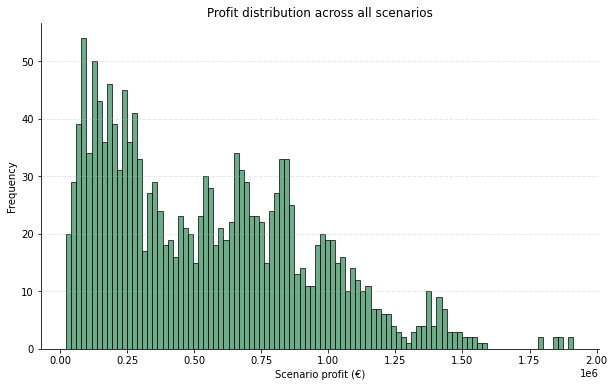

In [92]:
profits = np.zeros(W)


# The optimal hourly DA offers and expected profit.
print("Optimal Offers for each hour:")
p_DA_sol = np.array([p_DA[t].X for t in range(T)])
print(p_DA_sol)
print("-"* 30)
print("Expected Profit:", m.ObjVal)


# Loops through all scenarios and calculates each profit across 24 h
for w in range(W):
    profit_w = 0
    for t in range(T):
        # Profit (assuming 0 marginal cost) is DA revenue + imbalance revenue
        profit_w += (
            DA_lambda[w, t] * p_DA_sol[t]
            + lambda_bal[w, t] * (real_prod[w, t] - p_DA_sol[t])
        )
    profits[w] = profit_w
    
    
plt.figure(figsize=(10, 6))
plt.hist(profits, bins=100, edgecolor='black', color='seagreen', alpha=0.7)
plt.xlabel("Scenario profit (€)")
plt.ylabel("Frequency")
plt.title("Profit distribution across all scenarios")
plt.grid(alpha=0.3, linestyle='--', linewidth=1, axis='y')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

## Model 1.2

In [93]:
# Init
real_prod = np.zeros((W, T))
DA_lambda = np.zeros((W, T))
SI = np.zeros((W, T))
w = 0
  

# Creates a scenario for each combination 
for i in range(N_wind):
    for j in range(N_price):
        for k in range(N_si):
            real_prod[w, :] = wind_scenarios[i, :]
            DA_lambda[w, :] = price_scenarios[j, :]
            SI[w, :] = si_scenarios[k, :]
            w += 1
print(w)

print(np.min(real_prod), np.max(real_prod))
print(np.min(DA_lambda), np.max(DA_lambda))
print(np.min(SI), np.max(SI)) 


# Model
m2 = gp.Model("model_1_2")

# Decision variable
p_DA2 = m2.addVars(T, lb=0, ub=capacity, name="p_DA2")

# Deviation variables
Delta_up = m2.addVars(W, T, lb=0, ub=capacity, name="Delta_up")
Delta_down = m2.addVars(W, T, lb=0, ub=capacity, name="Delta_down")


# Constraints
for w in range(W):
    for t in range(T):
        m2.addConstr(Delta_up[w,t] >= real_prod[w,t] - p_DA2[t])
        m2.addConstr(Delta_down[w,t] >= p_DA2[t] - real_prod[w,t])

# Prices
lambda_up = 1.25 * DA_lambda
lambda_down = 0.85 * DA_lambda

# Objective
m2.setObjective(
    gp.quicksum(
        pi * (
            DA_lambda[w,t] * p_DA2[t]

            # Overproduction compared to DA offer
            + Delta_up[w,t] * (
                SI[w,t] * lambda_up[w,t]
                + (1 - SI[w,t]) * DA_lambda[w,t]
            )

            # Underproduction compared to DA
            - Delta_down[w,t] * (
                SI[w,t] * DA_lambda[w,t]
                + (1 - SI[w,t]) * lambda_down[w,t]
            )
        )
        for w in range(W)
        for t in range(T)
    ),
    gp.GRB.MAXIMIZE
)

m2.optimize()


1600
0.1865 449.512
-1.03 370.1
0.0 1.0
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 6600U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 76800 rows, 76824 columns and 153600 nonzeros
Model fingerprint: 0x323aef0d
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-06, 1e+02]
  Bounds range     [5e+02, 5e+02]
  RHS range        [2e-01, 4e+02]
Presolve removed 38720 rows and 38720 columns
Presolve time: 0.05s
Presolved: 38080 rows, 38104 columns, 76160 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier performed 0 iterations in 0.09 seconds (0.07 work units)
Barrier solve interrupted - model solved by another algorithm


Solved with dual simplex
Iteration    Objective       Primal Inf.    Dual Inf.      Time

Optimal Offers for each hour:
[500.     500.     500.     500.     500.     500.     500.     500.
 500.     372.2905 500.     500.     500.     500.     500.     500.
 500.     500.     500.     500.     500.     500.     500.     500.    ]
------------------------------
Expected Profit: 1952055.0029337318


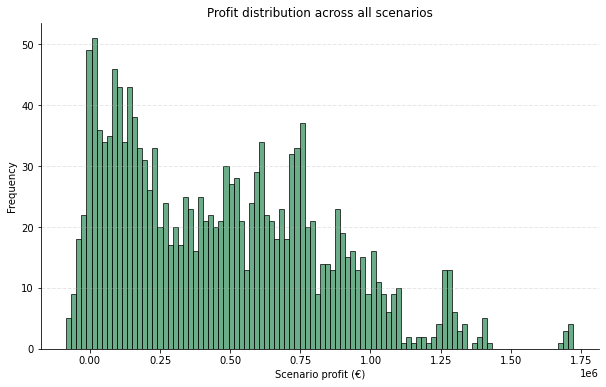

In [94]:
profits2 = np.zeros(W)

# The optimal hourly DA offers and expected profit.
print("Optimal Offers for each hour:")
p_DA_sol2 = np.array([p_DA2[t].X for t in range(T)])
print(p_DA_sol2)
print("-"* 30)
print("Expected Profit:", m2.ObjVal)


# Loops through all scenarios and calculates each profit across 24 h
for w in range(W):
    profit_w = 0
    for t in range(T):
        # Profit (assuming 0 marginal cost) is DA revenue + imbalance revenue
        profit_w += (
            DA_lambda[w, t] * p_DA_sol2[t]
            + lambda_bal[w, t] * (real_prod[w, t] - p_DA_sol2[t])
        )
    profits2[w] = profit_w
    
    
plt.figure(figsize=(10, 6))
plt.hist(profits2, bins=100, edgecolor='black', color='seagreen', alpha=0.7)
plt.xlabel("Scenario profit (€)")
plt.ylabel("Frequency")
plt.title("Profit distribution across all scenarios")
plt.grid(alpha=0.3, linestyle='--', linewidth=1, axis='y')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()